# Lab 1 - EDA e baseline stabile con feature ResNet-18

Questo notebook copre la prima parte del laboratorio: **Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline**.

L'obiettivo e' capire il dataset GTSRB, motivare il preprocessing e costruire una baseline riproducibile usando una ResNet-18 pre-addestrata come estrattore di feature e una SVM lineare come classificatore finale.

> **Execution note**
>
> Gli output visibili sono stati prodotti durante le esecuzioni finali o di validazione del laboratorio. Nella versione di consegna i training costosi sono disattivati di default quando sono controllati da flag; checkpoint e artefatti salvati vengono usati per consultazione rapida.

## Nota di trasparenza

Risorse esterne usate:

- dataset GTSRB tramite `torchvision.datasets.GTSRB`;
- ResNet-18 pre-addestrata su ImageNet tramite `torchvision.models`;
- SVM lineare tramite `scikit-learn`.

## Nota sul codice modulare

Le funzioni importate da `src/dla_lab1` sono documentate direttamente nei file `.py`, con una nota in italiano che spiega a cosa servono. In questo modo il notebook resta piu' pulito e il codice riutilizzabile resta spiegabile anche fuori dal notebook.

## 1. Setup essenziale

Il setup resta breve: imposto il path del progetto, carico la configurazione e scelgo il device. Il kernel usato per eseguire i notebook finali e' `Python 3 (ipykernel)` dell'ambiente Conda `clip_lora`, che contiene PyTorch, Torchvision, NumPy, pandas e scikit-learn.

In [2]:
from pathlib import Path
import os
import sys
import time

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mpl_config_dir = ROOT / "artifacts" / "matplotlib"
mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from torch.utils.data import DataLoader

sys.path.insert(0, str(ROOT / "src"))

from dla_lab1.config import load_config
from dla_lab1.data import load_gtsrb, read_test_metadata, read_training_metadata
from dla_lab1.eda import class_distribution, metadata_summary
from dla_lab1.features import extract_features, load_feature_cache, save_feature_cache
from dla_lab1.models import build_feature_extractor
from dla_lab1.seed import seed_everything
from dla_lab1.transforms import build_transforms
from dla_lab1.visualize import plot_class_distribution

config = load_config(ROOT / "config" / "config.yaml")
seed_everything(config["project"]["seed"])

DATA_ROOT = ROOT / config["paths"]["data_root"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# La cache viene letta se presente; l'estrazione completa richiede consenso esplicito.
RUN_FEATURE_EXTRACTION = False


Project root: DLA_1
Data root: DLA_1\data
Device: cuda
GPU: NVIDIA GeForce RTX 2050


## 2. Caricamento del dataset grezzo

All'inizio carico le immagini senza trasformazioni. Questo serve per vedere le dimensioni originali, la qualita' visiva e lo sbilanciamento delle classi prima di applicare resize e normalizzazione.

In [3]:
ds_train_raw = load_gtsrb(DATA_ROOT, split="train", transform=None, download=False)
ds_test_raw = load_gtsrb(DATA_ROOT, split="test", transform=None, download=False)

print(f"Training samples: {len(ds_train_raw)}")
print(f"Test samples: {len(ds_test_raw)}")

first_image, first_label = ds_train_raw[0]
second_image, second_label = ds_train_raw[1]
print(f"First image size: {first_image.size}, class: {first_label}")
print(f"Second image size: {second_image.size}, class: {second_label}")

Training samples: 26640
Test samples: 12630
First image size: (29, 30), class: 0
Second image size: (30, 30), class: 0


**Commento.** Il training set locale contiene 26.640 immagini e il test set 12.630 immagini. Le prime due immagini hanno gia' dimensioni leggermente diverse: questo conferma che prima del batching serve un preprocessing che renda tutte le immagini della stessa dimensione.

## 3. Ispezione visiva

Visualizzo alcuni campioni grezzi. Questa cella non serve ad addestrare il modello: serve a capire che tipo di variabilita' dovra' gestire il classificatore.

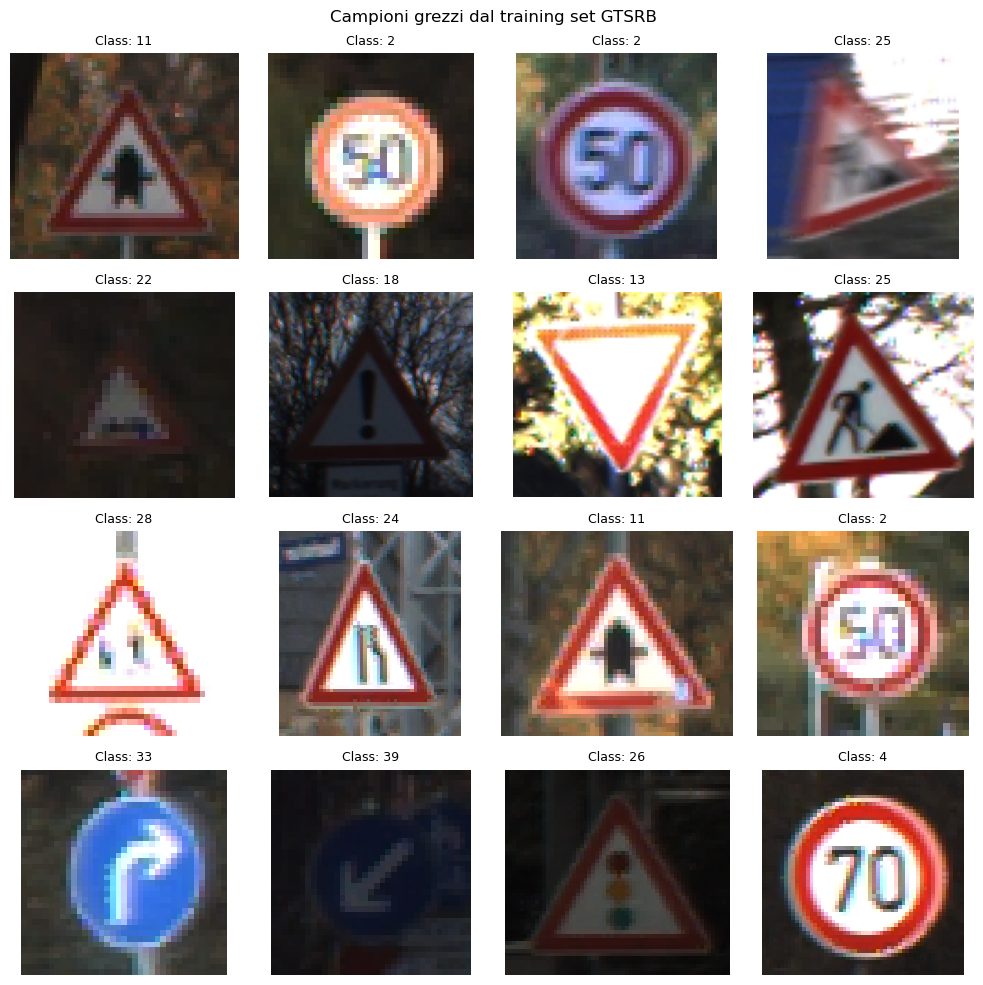

In [4]:
num_samples = 16
rng = np.random.default_rng(config["project"]["seed"])
random_indices = rng.choice(len(ds_train_raw), num_samples, replace=False)

plt.figure(figsize=(10, 10))
for plot_idx, sample_idx in enumerate(random_indices):
    image, label = ds_train_raw[int(sample_idx)]
    plt.subplot(4, 4, plot_idx + 1)
    plt.imshow(image)
    plt.title(f"Class: {label}", fontsize=9)
    plt.axis("off")

plt.suptitle("Campioni grezzi dal training set GTSRB")
plt.tight_layout()
plt.show()

**Commento.** Dall'ispezione visiva ci aspettiamo immagini con illuminazione, qualita', angolazione e dimensioni diverse. Questo giustifica trasformazioni semplici e stabili: resize a una dimensione comune e normalizzazione coerente con il backbone pre-addestrato.

## 4. Analisi numerica del dataset

Uso i file CSV del dataset per calcolare dimensioni, numero di classi e distribuzione delle etichette. Questo e' piu' veloce che aprire ogni immagine.

In [5]:
train_meta = read_training_metadata(DATA_ROOT)
test_meta = read_test_metadata(DATA_ROOT)

summary = metadata_summary(train_meta)
summary

{'num_samples': 26640,
 'num_classes': 43,
 'min_class_count': 150,
 'max_class_count': 1500,
 'width_min': 25,
 'width_max': 243,
 'width_mean': 50.93378378378378,
 'height_min': 25,
 'height_max': 225,
 'height_mean': 50.36512762762763}

In [6]:
train_meta[["Height", "Width"]].describe()

,Height,Width
count,26640.000000,26640.000000
mean,50.365128,50.933784
std,23.161523,24.373418
min,25.000000,25.000000
25%,35.000000,35.000000
50%,43.000000,43.000000
75%,58.000000,58.000000
max,225.000000,243.000000


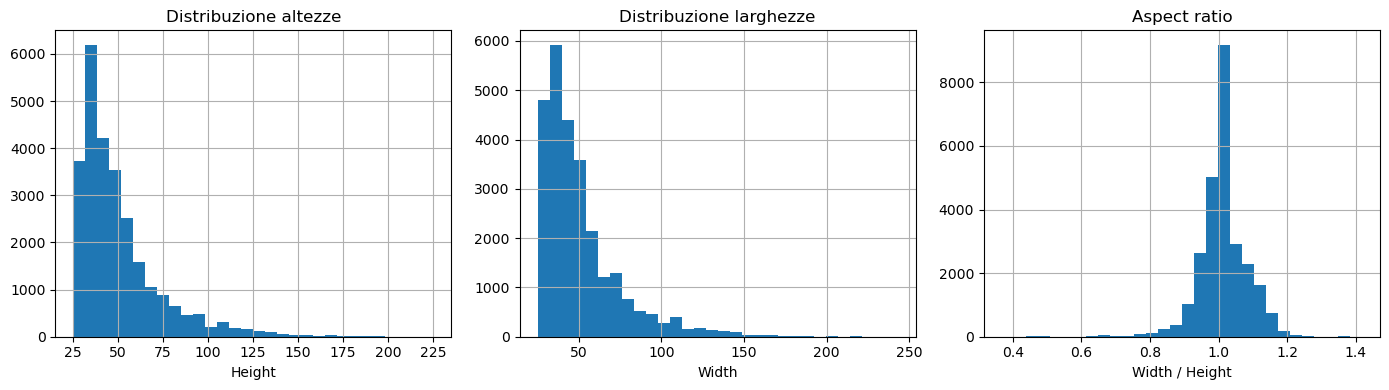

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
train_meta["Height"].hist(ax=axes[0], bins=30)
axes[0].set_title("Distribuzione altezze")
axes[0].set_xlabel("Height")

train_meta["Width"].hist(ax=axes[1], bins=30)
axes[1].set_title("Distribuzione larghezze")
axes[1].set_xlabel("Width")

aspect_ratio = train_meta["Width"] / train_meta["Height"]
aspect_ratio.hist(ax=axes[2], bins=30)
axes[2].set_title("Aspect ratio")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()

**Commento sui risultati numerici.** La run locale ha dato questi valori principali:

- campioni train: **26.640**;
- classi: **43**;
- classe meno rappresentata: **150 immagini**;
- classe piu' rappresentata: **1.500 immagini**;
- larghezza media: circa **50,93 px**, con massimo **243 px**;
- altezza media: circa **50,37 px**, con massimo **225 px**.

Quindi il dataset non e' bilanciato e le immagini non hanno dimensione fissa. La media e' vicina a 50x50, ma esistono outlier piu' grandi e molte immagini piccole. Per questo uso immagini 64x64: e' una scelta abbastanza economica per la GPU e sufficiente per non comprimere troppo i segnali.

## 5. Distribuzione delle classi

Lo sbilanciamento tra classi e' importante: una accuracy globale puo' sembrare buona anche se il modello va male sulle classi rare. Per questo guardo anche precision, recall e f1-score per classe nella baseline.

,class_id,count
0,0,150
1,1,1500
2,2,1500
3,3,960
4,4,1320


,class_id,count
0,0,150
19,19,150
37,37,150
29,29,180
24,24,180
42,42,180
32,32,180
27,27,180


,class_id,count
1,1,1500
2,2,1500
13,13,1440
12,12,1410
38,38,1380
10,10,1350
4,4,1320
5,5,1260


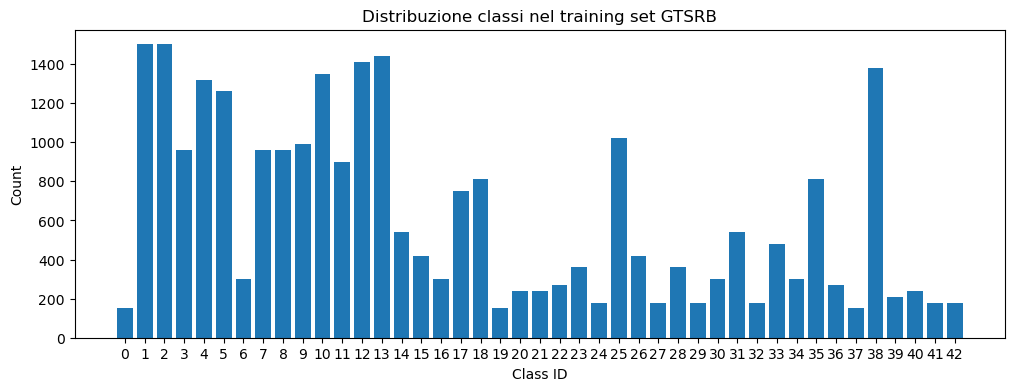

In [8]:
class_counts = class_distribution(train_meta)
display(class_counts.head())
display(class_counts.sort_values("count").head(8))
display(class_counts.sort_values("count", ascending=False).head(8))

plot_class_distribution(train_meta["ClassId"], title="Distribuzione classi nel training set GTSRB");

**Commento.** Le classi 0, 19 e 37 hanno solo 150 esempi, mentre classi come 1 e 2 arrivano a 1.500 esempi. Questo e' uno sbilanciamento di circa 10:1. Nelle parti successive del laboratorio sara' sensato confrontare CrossEntropy standard, pesi di classe o Focal Loss, ma per questa prima baseline mantengo il modello semplice.

## 6. Preprocessing scelto

La ResNet-18 pre-addestrata su ImageNet si aspetta immagini normalizzate con media e deviazione standard di ImageNet. Qui uso:

1. resize a `64x64`;
2. conversione in tensore float;
3. normalizzazione ImageNet.

Non uso data augmentation nella baseline, perche' la baseline deve essere stabile e facile da riprodurre.

In [9]:
image_size = config["dataset"]["image_size"]
eval_transform = build_transforms(image_size=image_size, train=False)

ds_train = load_gtsrb(DATA_ROOT, split="train", transform=eval_transform, download=False)
ds_test = load_gtsrb(DATA_ROOT, split="test", transform=eval_transform, download=False)

image, label = ds_train[0]
print(f"Transformed image shape: {tuple(image.shape)}")
print(f"Label: {label}")

Transformed image shape: (3, 64, 64)
Label: 0


## 7. Baseline stabile: ResNet-18 come feature extractor

In questa baseline non addestro la CNN. Uso ResNet-18 pre-addestrata solo per trasformare ogni immagine in un vettore di feature da 512 dimensioni. Poi alleno una SVM lineare su questi vettori.

Nota pratica: se la cache `resnet18_gtsrb_features_64x64.pt` esiste, la carico direttamente. Se non esiste, la cella estrae le feature e le salva. Questo rende il notebook piu' veloce da rieseguire.

In [10]:
legacy_cache = ROOT / "resnet18_gtsrb_features_64x64.pt"
artifact_cache = ROOT / "artifacts" / "features" / "resnet18_gtsrb_features_64x64.pt"
feature_cache = legacy_cache if legacy_cache.exists() else artifact_cache

if feature_cache.exists():
    print(f"Carico feature gia' estratte da: {feature_cache}")
    cache = load_feature_cache(feature_cache)
    train_feats = cache["train_feats"]
    train_classes = cache["train_classes"]
    test_feats = cache["test_feats"]
    test_classes = cache["test_classes"]
elif RUN_FEATURE_EXTRACTION:
    print("Cache non trovata: estraggo le feature con ResNet-18.")
    batch_size = config["hardware"]["batch_size_feature_extraction"]
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    feature_model = build_feature_extractor("resnet18", weights="DEFAULT")
    train_feats, train_classes = extract_features(feature_model, dl_train, device)
    test_feats, test_classes = extract_features(feature_model, dl_test, device)
    feature_cache = save_feature_cache(
        artifact_cache,
        train_feats=train_feats,
        train_classes=train_classes,
        test_feats=test_feats,
        test_classes=test_classes,
    )
else:
    train_feats = train_classes = test_feats = test_classes = None
    print("Feature extraction non eseguita. Imposta RUN_FEATURE_EXTRACTION = True per crearne la cache.")

if train_feats is not None:
    print(f"Train features: {tuple(train_feats.shape)}")
    print(f"Test features: {tuple(test_feats.shape)}")


Carico feature gia' estratte da: DLA_1\resnet18_gtsrb_features_64x64.pt
Train features: (26640, 512)
Test features: (12630, 512)


**Commento.** Le feature hanno shape `(26640, 512)` per il train e `(12630, 512)` per il test. Il numero 512 e' la dimensione del vettore prodotto da ResNet-18 prima del classificatore finale. Questo conferma che la rete sta funzionando da estrattore di rappresentazioni.

## 8. Classificatore SVM lineare

Uso `SVC(kernel='linear')`, come nel metodo originale. In questo modo il risultato viene prodotto direttamente in questo notebook ed e' confrontabile con le sezioni successive.


In [11]:
if train_feats is not None:
    start = time.time()
    svm = SVC(kernel="linear", C=1.0, cache_size=2000)
    svm.fit(train_feats.numpy(), train_classes.numpy())
    test_predictions = svm.predict(test_feats.numpy())
    elapsed = time.time() - start

    baseline_accuracy = accuracy_score(test_classes.numpy(), test_predictions)
    print(f"Fit time: {elapsed:.2f} seconds")
    print(f"Baseline accuracy: {baseline_accuracy:.4f}")
else:
    print("SVM non addestrata in modalita' rapida; consulta results/test_metrics.csv.")


Fit time: 114.97 seconds
Baseline accuracy: 0.6412


In [12]:
if train_feats is not None:
    report = classification_report(
        test_classes.numpy(),
        test_predictions,
        digits=4,
        zero_division=0,
    )
    print(report)
else:
    display(pd.read_csv(ROOT / "results" / "test_metrics.csv").head(1))


              precision    recall  f1-score   support

           0     0.2083    0.1667    0.1852        60
           1     0.5216    0.6889    0.5937       720
           2     0.4786    0.4920    0.4852       750
           3     0.3412    0.3556    0.3482       450
           4     0.6028    0.5818    0.5921       660
           5     0.5387    0.5190    0.5287       630
           6     0.9764    0.8267    0.8953       150
           7     0.5795    0.5267    0.5518       450
           8     0.4603    0.3733    0.4123       450
           9     0.9122    0.7792    0.8404       480
          10     0.8432    0.8879    0.8649       660
          11     0.4760    0.5905    0.5271       420
          12     0.9480    0.9768    0.9622       690
          13     0.9532    0.9903    0.9714       720
          14     0.9080    0.8407    0.8731       270
          15     0.9902    0.9667    0.9783       210
          16     0.8857    0.8267    0.8552       150
          17     0.9738    

**Commento sui risultati della baseline.** La run ha ottenuto:

- accuracy: **0,6412**;
- macro f1-score: **0,5635**;
- weighted f1-score: **0,6379**.

La differenza tra macro e weighted f1-score e' importante: il weighted score pesa di piu' le classi frequenti, mentre il macro score tratta tutte le classi allo stesso modo. Il fatto che il macro f1 sia piu' basso indica che la baseline soffre sulle classi rare o piu' difficili.

Alcune classi sono riconosciute bene, per esempio 12 e 13 hanno f1-score sopra 0,93. Altre classi, come 0, 23, 24, 28, 30, 37 e 41, hanno risultati molto piu' bassi. Questo e' coerente con lo sbilanciamento osservato e con la difficolta' di alcune immagini piccole o visivamente simili.

## Conclusione della prima parte

In questa prima parte ho verificato che:

1. il dataset GTSRB locale viene caricato correttamente;
2. le immagini hanno dimensioni variabili, quindi e' necessario un preprocessing comune;
3. il dataset e' fortemente sbilanciato tra le 43 classi;
4. una ResNet-18 pre-addestrata puo' essere usata come feature extractor senza addestrare la CNN;
5. una SVM lineare sulle feature ResNet-18 fornisce una baseline semplice e riproducibile.

La baseline non e' ancora il modello finale: l'accuracy intorno al 64% lascia spazio a miglioramenti. Pero' e' utile perche' stabilisce un riferimento chiaro: ogni fine-tuning successivo dovra' essere confrontato contro questa baseline, non solo in termini di accuracy ma anche guardando macro f1-score e classi rare.

## Referenced functions and source files

| Function/class | Defined in | Purpose |
| --- | --- | --- |
| `load_config` | `src/dla_lab1/config.py` | Caricamento configurazione del laboratorio. |
| `build_dataloaders` / `build_retrieval_dataloaders` | `src/dla_lab1/data.py` | Preparazione split, loader e pipeline GTSRB. |
| `run_finetuning` | `src/dla_lab1/experiments.py` | Esecuzione controllata degli esperimenti di fine-tuning. |
| `classification_metrics` | `src/dla_lab1/evaluate.py` | Calcolo metriche di classificazione. |
| `extract_features` | `src/dla_lab1/features.py` | Estrazione feature per baseline e retrieval. |
